In [1]:
import sys
from pathlib import Path

sys.path.append(f"{Path().absolute().parent}")

In [2]:
from __future__ import annotations

from MRO_library import *
import plots
from radp.digital_twin.utils.gis_tools import GISTools

### Data Preprocessing

In [3]:
# ue_data = pd.read_csv('data/sim_data/UE_data_20UE_100ticks.csv')
ue_data = pd.read_csv("data/sim_data/100UE_500Ticks.csv")
ue_data = ue_data.rename(
    columns={"lon": "longitude", "lat": "latitude"}
)  # Delete Later

ue_data

,mock_ue_id,longitude,latitude,tick
0,0,342.728331,-63.720382,0
1,1,-145.898645,107.462975,0
2,2,158.058351,81.763544,0
3,3,-170.344382,-12.675260,0
4,4,196.076144,-47.137734,0
...,...,...,...,...
49995,95,12.228392,157.123009,499
49996,96,-340.878584,11.878862,499
49997,97,321.623408,172.472468,499
49998,98,173.640984,-45.488980,499


In [4]:
topology = pd.read_csv("data/sim_data/topology.csv")

topology.loc[topology["cell_id"] == "cell_1", "cell_lat"] = -90
topology.loc[topology["cell_id"] == "cell_2", "cell_lat"] = 0
topology.loc[topology["cell_id"] == "cell_3", "cell_lat"] = 90

topology.loc[topology["cell_id"] == "cell_1", "cell_lon"] = -180
topology.loc[topology["cell_id"] == "cell_2", "cell_lon"] = 0
topology.loc[topology["cell_id"] == "cell_3", "cell_lon"] = 180

topology.loc[topology["cell_id"] == "cell_1", "cell_carrier_freq_mhz"] = 1500
topology.loc[topology["cell_id"] == "cell_2", "cell_carrier_freq_mhz"] = 1500
topology.loc[topology["cell_id"] == "cell_3", "cell_carrier_freq_mhz"] = 1800

topology

,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz
0,-90.0,-180.0,cell_1,0,1500
1,0.0,0.0,cell_2,120,1500
2,90.0,180.0,cell_3,240,1800


In [5]:
data = concatenate_ue_to_topology(ue_data, topology)
data = connect_ue_to_all_cells(data, topology)

In [6]:
# Calculating distance and received power
data["distance_km"] = data.apply(
    lambda row: GISTools.get_log_distance(
        row["latitude"], row["longitude"], row["cell_lat"], row["cell_lon"]
    ),
    axis=1,
)
data["cell_rxpower_dbm"] = data.apply(
    lambda row: calculate_received_power(
        row["distance_km"], row["cell_carrier_freq_mhz"]
    ),
    axis=1,
)
# Rename Mock UE ID to UE ID for consistency
data = data.rename(columns={"mock_ue_id": "ue_id"})
data["ue_id"] = data["ue_id"].astype(int)
topology["cell_id"] = topology["cell_id"].str.replace("cell_", "").astype(int)
data["cell_id"] = data["cell_id"].str.extract("(\d+)").astype(int)
data = data.rename(columns={"latitude": "loc_y", "longitude": "loc_x"})
data["relative_bearing"] = data.apply(
    lambda row: GISTools.get_relative_bearing(
        row["cell_az_deg"], row["cell_lat"], row["cell_lon"], row["loc_y"], row["loc_y"]
    ),
    axis=1,
)
# data = data.rename(columns={'cell_rxpower_dbm': 'rsrp_dbm'})
data = add_sinr_column(data)

### Perform Attachment w/ Hyst & TTT

In [7]:
data

,ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,sinr_db
0,0,342.728331,-63.720382,0.0,-90.0,-180.0,1,0,1500,14.888948,-96.429105,116.279618,-26.964459
1,0,342.728331,-63.720382,0.0,0.0,0.0,2,120,1500,15.794377,-96.941875,83.881476,-26.964459
2,0,342.728331,-63.720382,0.0,90.0,180.0,3,240,1800,16.655289,-98.986494,183.720382,-26.964459
3,1,-145.898645,107.462975,0.0,-90.0,-180.0,1,0,1500,16.711060,-97.431905,107.462975,-26.630862
4,1,-145.898645,107.462975,0.0,0.0,0.0,2,120,1500,15.945768,-97.024734,223.296054,-26.630862
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,98,173.640984,-45.488980,499.0,0.0,0.0,2,120,1500,16.519228,-97.331620,95.032239,-25.044518
149996,98,173.640984,-45.488980,499.0,90.0,180.0,3,240,1800,16.529044,-98.920405,165.488980,-25.044518
149997,99,96.764921,-21.916692,499.0,-90.0,-180.0,1,0,1500,15.840886,-96.967415,158.083308,-26.892803
149998,99,96.764921,-21.916692,499.0,0.0,0.0,2,120,1500,16.187352,-97.155341,102.852929,-26.892803


#### HyperParameters

In [8]:
hyst = 0.25  # 0<hyst
ttt = 5  # 2<ttt< total ticks
rlf_threshold = -98.0

In [9]:
attached_df = perform_attachment_hyst_ttt(data, hyst, ttt, rlf_threshold)

In [10]:
attached_df

,ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,sinr_db
0,0.0,342.728331,-63.720382,0.0,-90.0,-180.0,1.0,0.0,1500.0,14.888948,-96.429105,116.279618,-26.964459
4,1.0,-145.898645,107.462975,0.0,0.0,0.0,2.0,120.0,1500.0,15.945768,-97.024734,223.296054,-26.630862
7,2.0,158.058351,81.763544,0.0,0.0,0.0,2.0,120.0,1500.0,16.201402,-97.162877,248.152647,-26.177949
9,3.0,-170.344382,-12.675260,0.0,-90.0,-180.0,1.0,0.0,1500.0,15.968168,-97.036927,167.324740,-26.780539
12,4.0,196.076144,-47.137734,0.0,-90.0,-180.0,1.0,0.0,1500.0,15.378146,-96.709905,132.862266,-26.897276
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95.0,12.228392,157.123009,499.0,0.0,0.0,2.0,120.0,1500.0,16.658506,-97.404546,197.344341,-26.920186
96,96.0,-340.878584,11.878862,499.0,0.0,0.0,2.0,120.0,1500.0,14.728899,-96.335231,284.379889,-26.729932
97,97.0,321.623408,172.472468,499.0,0.0,0.0,2.0,120.0,1500.0,16.568943,-97.357721,195.247954,-21.794270
98,98.0,173.640984,-45.488980,499.0,-90.0,-180.0,1.0,0.0,1500.0,15.415891,-96.731198,134.511020,-25.044518


In [11]:
print(f"Switches: {count_switches(attached_df)}, RLF: {count_rlf(attached_df)}")
print(f"MRO Score: {calculate_mro_metric(attached_df)}")

Switches: 42, RLF: 0
MRO Score: 497.9


In [12]:
# plots.plot_scatter2(attached_df, topology)

In [13]:
# ue_ids = attached_df['ue_id'].unique()
# for i in ue_ids:
#    plots.plot_ue_rxpower_over_time(attached_df, data, i)
#    plots.individual_scatter_plot(attached_df, data, i)

## Optimizing Hyst & TTT

In [14]:
max_diff = find_hyst_diff(attached_df)
num_ticks = attached_df["tick"].nunique()
print(f"Max Hyst Diff: {max_diff}\nNum Ticks: {num_ticks}")

Max Hyst Diff: 9.59534192167132
Num Ticks: 500


In [15]:
epochs = 100

hyst_range = [0, max_diff]
ttt_range = [2, num_ticks]
score = pd.DataFrame(columns=["hyst", "ttt", "score"])

In [16]:
print(f"{'Epoch':<6} {'Hyst':<14} {'TTT':<6} {'MRO Metric':<12}")
print("-" * 40)

for i in range(epochs):
    while True:
        hyst = np.random.uniform(hyst_range[0], hyst_range[1])
        ttt = np.random.randint(ttt_range[0], ttt_range[1])
        if ttt not in score["ttt"].values or hyst not in score["hyst"].values:
            break

    attached_df = perform_attachment_hyst_ttt(data, hyst, ttt, rlf_threshold)
    mro_metric = calculate_mro_metric(attached_df)

    print(f"{i:<6} {hyst:<14.10f} {ttt:<6} {mro_metric:<12.6f}")
    score.loc[len(score)] = [hyst, ttt, mro_metric]

Epoch  Hyst           TTT    MRO Metric  
----------------------------------------
0      8.9235144243   185    495.600000  
1      1.9906088412   461    489.900000  
2      7.1998475324   433    490.850000  
3      1.8124649449   468    489.800000  
4      4.3450956363   260    493.850000  
5      4.9687232810   390    491.900000  
6      4.2514868331   412    491.400000  
7      8.0388117185   294    493.300000  
8      2.6233090302   75     498.650000  
9      2.0704174510   170    495.950000  
10     3.0587426325   90     498.250000  
11     4.7854440675   204    495.200000  
12     1.2828937148   99     498.100000  
13     7.1719904431   69     498.700000  
14     9.0026781122   237    494.200000  
15     6.0382800391   224    494.650000  
16     2.5685039111   407    491.550000  
17     4.9844259974   252    493.950000  
18     2.2140015139   55     499.000000  
19     8.5155057028   325    492.800000  
20     8.9906284278   15     499.700000  
21     2.2234840171   211    495.00

In [17]:
score.loc[score["score"].idxmax()]

hyst       8.9128
ttt        8.0000
score    499.8500
Name: 51, dtype: float64

In [18]:
plots.plot_3d_hyst_ttt_score(score)

## Debugging RLF

In [19]:
attached_df["sinr_db"].describe()

count    50000.000000
mean       -25.770176
std          1.821918
min        -26.970992
25%        -26.909803
50%        -26.727970
75%        -25.368711
max        -20.026312
Name: sinr_db, dtype: float64

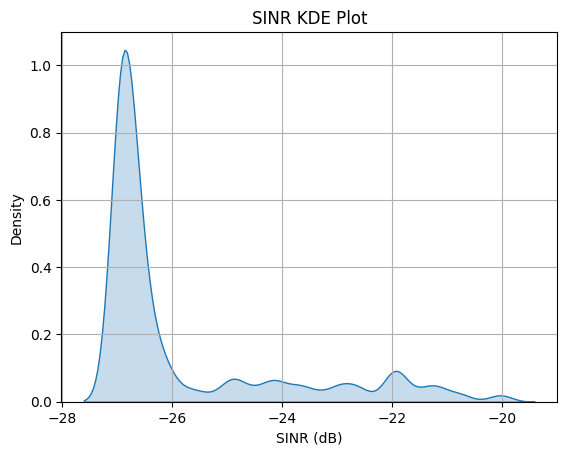

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(attached_df["sinr_db"], fill=True)
plt.title("SINR KDE Plot")
plt.xlabel("SINR (dB)")
plt.grid(True)
plt.show()

In [26]:
id = 5
print(attached_df[attached_df["ue_id"] == id][["sinr_db"]].reset_index(drop=True))

       sinr_db
0   -26.953243
1   -26.953243
2   -26.953243
3   -26.953243
4   -26.953243
..         ...
495 -26.953243
496 -26.953243
497 -26.953243
498 -26.953243
499 -26.953243

[500 rows x 1 columns]
